# 1. Import Library & Load Data
Langkah pertama adalah memuat pustaka yang dibutuhkan dan membaca dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Memuat dataset
df = pd.read_csv('newdata/sleep_health_dataset.csv')
print(f'Dimensi dataset: {df.shape}')
display(df.head())

Dimensi dataset: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


# 2. Pemeriksaan Kualitas Data
Memastikan dataset bebas dari missing values dan data duplikat.

In [2]:
# Cek Missing Values
print('Total Missing Values:', df.isnull().sum().sum())

# Cek Duplikasi Baris
print('Total Data Duplikat:', df.duplicated().sum())

Total Missing Values: 0
Total Data Duplikat: 0


# 3. Analisis Distribusi Target (Imbalanced Data)
Menganalisis proporsi kelas pada target sleep_disorder_risk.

In [3]:
target_dist = df['sleep_disorder_risk'].value_counts()
target_percent = df['sleep_disorder_risk'].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({'Jumlah': target_dist, 'Persentase (%)': target_percent})
display(dist_df)

,Jumlah,Persentase (%)
sleep_disorder_risk,,
Healthy,54156,54.156
Mild,33479,33.479
Moderate,8299,8.299
Severe,4066,4.066


# 4. Feature Selection & Pemisahan Variabel
Membuang kolom `person_id` (identifier unik), `country` (bias geografis), dan `day_type` (zero importance), lalu memisahkan fitur independen (X) dan dependen (y).

In [4]:
# Membuang kolom person_id, country, dan day_type
df_cleaned = df.drop(columns=['person_id', 'country', 'day_type'])

# Memisahkan X dan y
X = df_cleaned.drop(columns=['sleep_disorder_risk'])
y = df_cleaned['sleep_disorder_risk']
print(f'Jumlah Fitur (X): {X.shape[1]}')

Jumlah Fitur (X): 28


# 5. Menentukan Fitur Kategorikal
Mendata fitur teks yang akan diproses secara native oleh CatBoost.

In [5]:
cat_features = X.select_dtypes(include=['object']).columns.tolist()
print('Daftar Fitur Kategorikal:')
print(cat_features)

Daftar Fitur Kategorikal:
['gender', 'occupation', 'chronotype', 'mental_health_condition', 'season']


C:\Users\ahmad\AppData\Local\Temp\ipykernel_19128\2375107116.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns.tolist()


# 6. Data Splitting
Membagi data (80% Train, 20% Test) dengan parameter stratify=y.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Jumlah Data Training: {X_train.shape[0]} baris')
print(f'Jumlah Data Testing: {X_test.shape[0]} baris')

Jumlah Data Training: 80000 baris
Jumlah Data Testing: 20000 baris


# 7. Inisialisasi Model CatBoost & Training
Melatih model CatBoost dengan penanganan imbalanced data (uto_class_weights).

In [7]:
from catboost import CatBoostClassifier

model_catboost = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    cat_features=cat_features,
    random_seed=42,
    verbose=100
)

model_catboost.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
    plot=False # Mencegah Jupyter crash akibat widget CatBoost
)

0:	learn: 1.3198462	test: 1.3201008	best: 1.3201008 (0)	total: 244ms	remaining: 4m 3s
100:	learn: 0.3943314	test: 0.4048513	best: 0.4048513 (100)	total: 15.1s	remaining: 2m 14s
200:	learn: 0.3014282	test: 0.3168501	best: 0.3168501 (200)	total: 29.4s	remaining: 1m 56s
300:	learn: 0.2538172	test: 0.2749213	best: 0.2749213 (300)	total: 43.4s	remaining: 1m 40s
400:	learn: 0.2274925	test: 0.2544362	best: 0.2544362 (400)	total: 57.7s	remaining: 1m 26s
500:	learn: 0.2087406	test: 0.2414478	best: 0.2414478 (500)	total: 1m 11s	remaining: 1m 11s
600:	learn: 0.1956737	test: 0.2339379	best: 0.2339379 (600)	total: 1m 26s	remaining: 57.1s
700:	learn: 0.1831548	test: 0.2269807	best: 0.2269668 (699)	total: 1m 40s	remaining: 42.8s
800:	learn: 0.1728157	test: 0.2215057	best: 0.2215057 (800)	total: 1m 54s	remaining: 28.4s
900:	learn: 0.1635904	test: 0.2167516	best: 0.2167516 (900)	total: 2m 8s	remaining: 14.1s
999:	learn: 0.1563740	test: 0.2142155	best: 0.2142020 (995)	total: 2m 22s	remaining: 0us

bestT

CatBoostClassifier(auto_class_weights='Balanced', cat_features=['gender', 'occupation', 'chronotype', 'mental_health_condition', 'season'], depth=6, iterations=1000, learning_rate=0.05, random_seed=42, verbose=100)

# 8. Evaluasi Model
Menguji performa model pada data testing.

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model_catboost.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)
print(f'Akurasi Model CatBoost: {akurasi * 100:.2f}%\n')

print('Laporan Klasifikasi:')
print(classification_report(y_test, y_pred))

Akurasi Model CatBoost: 95.19%

Laporan Klasifikasi:
              precision    recall  f1-score   support

     Healthy       1.00      0.99      1.00     10831
        Mild       0.98      0.92      0.95      6696
    Moderate       0.69      0.86      0.77      1660
      Severe       0.81      0.89      0.85       813

    accuracy                           0.95     20000
   macro avg       0.87      0.92      0.89     20000
weighted avg       0.96      0.95      0.95     20000



# 9. Penjelasan Model dengan XAI-SHAP
Menggunakan library SHAP untuk membongkar kotak hitam CatBoost dan melihat faktor gaya hidup mana yang paling berkontribusi.

In [9]:
import shap
from catboost import Pool

# MENCEGAH KERNEL CRASH PADA CATBOOST + SHAP:
# Kita tidak menggunakan shap.TreeExplainer karena library SHAP sering crash (segfault)
# saat memproses fitur kategorikal. Sebaliknya, kita menggunakan fitur Native SHAP dari CatBoost.

# 1. Ubah data testing menjadi CatBoost Pool
X_test_sampled = X_test.sample(1000, random_state=42)
pool_sampled = Pool(X_test_sampled, cat_features=cat_features)

# 2. Dapatkan nilai SHAP langsung dari fungsi bawaan CatBoost
# Output ini dijamin stabil dan menghasilkan array (jumlah_data, jumlah_kelas, jumlah_fitur + 1)
shap_vals_catboost = model_catboost.get_feature_importance(pool_sampled, type='ShapValues', thread_count=1)
print("Berhasil menghitung SHAP secara native!")

Berhasil menghitung SHAP secara native!


### A. SHAP Summary Plot (Analisis Global)
Visualisasi ini menunjukkan fitur mana yang secara keseluruhan paling mendominasi penentuan kelas target tertentu.

Urutan Kelas: ['Healthy' 'Mild' 'Moderate' 'Severe']


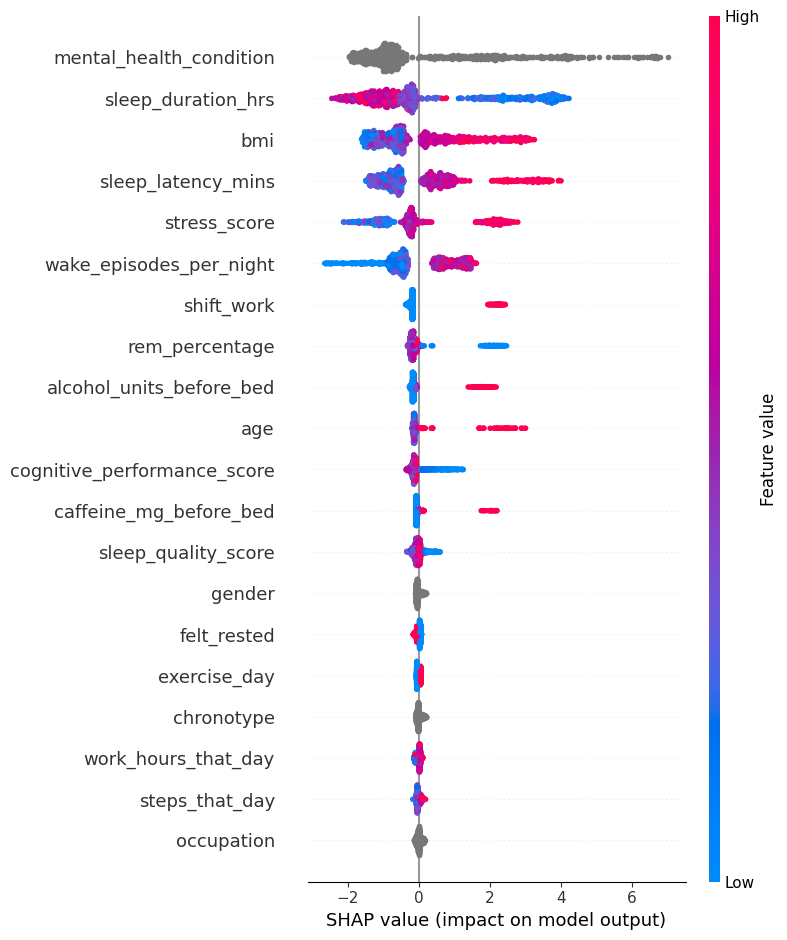

In [10]:
# Cek urutan kelas dari CatBoost
print("Urutan Kelas:", model_catboost.classes_)

# Dapatkan index untuk kelas 'Severe'
severe_idx = list(model_catboost.classes_).index('Severe')

# EKSTRAK DATA SHAP KHUSUS KELAS SEVERE
# CatBoost mengembalikan (samples, classes, features + 1 bias)
# Kita ambil semua baris (:), kelas severe, dan semua fitur kecuali kolom terakhir (:-1)
shap_values_severe = shap_vals_catboost[:, severe_idx, :-1]

# Menampilkan summary plot
shap.summary_plot(shap_values_severe, X_test_sampled)


### B. SHAP Force Plot (Analisis Lokal per Individu)
Bagaimana kita menjelaskan prediksi model untuk SATU orang pasien tertentu?

In [11]:
# Inisialisasi Javascript agar plot interaktif bisa muncul di notebook
shap.initjs()

# Pilih satu pasien secara acak (contoh: baris ke-10 di X_test_sampled)
pasien_ke = 129
data_pasien = X_test_sampled.iloc[pasien_ke]

print(f"Penjelasan Prediksi untuk Pasien Baris ke-{pasien_ke}:")

# Ambil nilai expected_value (bias) yang terletak di kolom paling terakhir (-1)
# Nilai ini sama untuk seluruh sampel, jadi kita ambil dari sampel ke-0 saja
expected_value_severe = shap_vals_catboost[0, severe_idx, -1]

# Generate visualisasi gaya dorong (Force Plot)
shap.force_plot(
    expected_value_severe, 
    shap_values_severe[pasien_ke, :], 
    data_pasien
)


Penjelasan Prediksi untuk Pasien Baris ke-129:
